# Étape 4 – Modélisation Avancée et Interprétabilité

## 04 - Bagging/Boosting, Deep Learning & Interprétation des Modèles

**Objectif** : Ce notebook prolonge le travail des notebooks précédents avec :
1. **Bagging / Boosting** : techniques d'ensemble avancées (BaggingClassifier, AdaBoost, HistGradientBoosting)
2. **Deep Learning** : réseaux de neurones avec MLPClassifier (Perceptron Multi-Couches)
3. **Interprétabilité** : comprendre *pourquoi* les modèles font leurs prédictions
4. **Conclusions** : bilan scientifique et métier de l'ensemble du projet

**Prérequis** : Avoir exécuté les notebooks `02-baseline-models.ipynb` et `03-advanced-metrics-optimization.ipynb`

**Rappel des résultats précédents** :
| Modèle | Accuracy | F1-macro |
|--------|----------|----------|
| SVM (RBF) | 0.8446 | 0.8479 |
| Random Forest | 0.8235 | 0.8143 |
| KNN (k=5) | 0.7694 | 0.7670 |
| Logistic Regression | 0.6563 | 0.6568 |

In [1]:
# =============================================
# IMPORTS
# =============================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import Counter
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split

# Modèles de Bagging / Boosting
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.tree import DecisionTreeClassifier

# Deep Learning (réseaux de neurones)
from sklearn.neural_network import MLPClassifier

# Métriques
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    f1_score,
    recall_score,
    matthews_corrcoef,
)

# Interprétabilité
from sklearn.inspection import permutation_importance

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
%matplotlib inline

print("Imports OK")

# =============================================
# COMMENTAIRE : Nouvelles bibliothèques
# =============================================
# - BaggingClassifier : entraîne plusieurs modèles sur des sous-échantillons
# - AdaBoostClassifier : boosting adaptatif, focus sur les erreurs
# - HistGradientBoostingClassifier : version rapide du gradient boosting
#   (inspiré de LightGBM/XGBoost, intégré nativement dans sklearn)
# - MLPClassifier : réseau de neurones (perceptron multi-couches)
# - permutation_importance : mesure l'importance des features
# - gc : garbage collector pour libérer la mémoire entre les étapes

Imports OK


## STEP 1 – Chargement et Préparation des Données

On recharge les données pour garder un notebook autonome.

In [2]:
# =============================================
# CHARGEMENT DES DONNÉES (ÉCHANTILLON)
# =============================================

print("="*70)
print("CHARGEMENT DES DONNÉES")
print("="*70)

DATA_DIR = "../data/COVID-19_Radiography_Dataset"
classes = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# ⚠️ On utilise un échantillon stratifié pour ne pas exploser la RAM
# (21 165 images × plusieurs modèles = trop lourd)
# On prend ~1200 images par classe → ~4800 images au total
MAX_PER_CLASS = 1200

X_list = []
labels = []

for class_name in classes:
    class_dir = os.path.join(DATA_DIR, class_name, 'images')
    if os.path.exists(class_dir):
        files = [f for f in os.listdir(class_dir) if f.endswith('.png')]
        # Échantillonner si la classe a plus d'images que le max
        np.random.seed(42)
        if len(files) > MAX_PER_CLASS:
            files = list(np.random.choice(files, MAX_PER_CLASS, replace=False))
        
        count = 0
        for img_file in files:
            img_path = os.path.join(class_dir, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                X_list.append(img)
                labels.append(class_name)
                count += 1
        print(f"   {class_name}: {count} images chargées (sur {len(os.listdir(class_dir))} disponibles)")
    else:
        print(f"   ⚠️ Dossier non trouvé: {class_dir}")

print(f"\n✅ Total: {len(X_list)} images chargées (échantillon stratifié)")
print(f"   Distribution: {Counter(labels)}")

# =============================================
# COMMENTAIRE : Pourquoi un échantillon ?
# =============================================
# Le dataset complet (21 165 images) + plusieurs modèles en mémoire
# = trop lourd pour un laptop classique.
# On prend un échantillon stratifié de ~4800 images, ce qui :
# - Préserve les proportions entre les classes
# - Donne des résultats représentatifs
# - Permet d'entraîner tous les modèles sans crash mémoire
#
# Note : les résultats des notebooks 02/03 étaient sur le dataset complet.
# Les scores ici seront légèrement différents mais les tendances restent.

CHARGEMENT DES DONNÉES
   COVID: 1200 images chargées (sur 3616 disponibles)
   Lung_Opacity: 1200 images chargées (sur 6012 disponibles)
   Normal: 1200 images chargées (sur 10192 disponibles)
   Viral Pneumonia: 1200 images chargées (sur 1345 disponibles)

✅ Total: 4800 images chargées (échantillon stratifié)
   Distribution: Counter({'COVID': 1200, 'Lung_Opacity': 1200, 'Normal': 1200, 'Viral Pneumonia': 1200})


In [3]:
# =============================================
# PRÉPARATION DES DONNÉES
# =============================================

print("="*70)
print("PRÉPARATION DES DONNÉES")
print("="*70)

# Redimensionnement à 64x64 (même taille que les notebooks précédents)
TARGET_SIZE = (64, 64)
X_small = np.array([cv2.resize(img, TARGET_SIZE) for img in X_list], dtype=np.float32) / 255.0

# On calcule l'image moyenne AVANT d'aplatir (pour l'interprétabilité plus tard)
mean_image = X_small.mean(axis=0)

# Images moyennes par classe (pour l'interprétabilité)
mean_images_per_class = {}
labels_array = np.array(labels)
for class_name in ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']:
    mask = labels_array == class_name
    mean_images_per_class[class_name] = X_small[mask].mean(axis=0)

X_flat = X_small.reshape(X_small.shape[0], -1)
print(f"Shape des images aplaties: {X_flat.shape}")

# ⚠️ Libérer la mémoire des images originales (on n'en a plus besoin)
del X_list, X_small
gc.collect()
print("🗑️ Mémoire libérée (images originales supprimées)")

# Encodage des labels
le = LabelEncoder()
y = le.fit_transform(labels)
n_classes = len(le.classes_)
print(f"Classes: {le.classes_}")

# Split train/test (même seed que les notebooks précédents)
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

# Libérer X_flat (on a X_train et X_test maintenant)
del X_flat
gc.collect()

# Normalisation StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} images, Test: {X_test.shape[0]} images")
print(f"Nombre de features: {X_train.shape[1]}")

# =============================================
# COMMENTAIRE : Gestion mémoire
# =============================================
# On supprime les variables lourdes dès qu'on n'en a plus besoin :
# - X_list (images originales 299x299) : très lourd en mémoire
# - X_small (images 64x64 en 2D) : remplacé par X_flat
# - X_flat : remplacé par X_train et X_test
# gc.collect() force Python à libérer la mémoire immédiatement.

PRÉPARATION DES DONNÉES
Shape des images aplaties: (4800, 4096)
🗑️ Mémoire libérée (images originales supprimées)
Classes: ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']

Train: 3840 images, Test: 960 images
Nombre de features: 4096


---

## PART A – Techniques de Bagging et Boosting

Le **Bagging** (Bootstrap Aggregating) et le **Boosting** sont des méthodes d'ensemble qui combinent plusieurs modèles "faibles" pour créer un modèle plus robuste.

| Technique | Principe | Avantage |
|-----------|----------|----------|
| **Bagging** | Entraîne des modèles en parallèle sur des sous-échantillons | Réduit la variance, évite l'overfitting |
| **AdaBoost** | Entraîne des modèles séquentiellement, focus sur les erreurs | Améliore les zones difficiles |
| **HistGradientBoosting** | Boosting par histogrammes (comme XGBoost/LightGBM) | Très rapide et performant |

### Différence clé Bagging vs Boosting :
- **Bagging** : chaque modèle vote de manière indépendante (parallèle)
- **Boosting** : chaque modèle corrige les erreurs du précédent (séquentiel)

In [4]:
# =============================================
# BAGGING CLASSIFIER
# =============================================

print("="*70)
print("PART A : BAGGING / BOOSTING")
print("="*70)

# --- 1. Bagging avec des arbres de décision ---
print("\n🔄 1. BaggingClassifier (base: DecisionTree)...")

start = time.time()
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=15, random_state=42),
    n_estimators=30,           # 30 arbres dans l'ensemble
    max_samples=0.7,           # chaque arbre voit 70% des données
    max_features=0.7,          # chaque arbre voit 70% des features
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)
t_bag = time.time() - start

acc_bag = accuracy_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag, average='macro')
mcc_bag = matthews_corrcoef(y_test, y_pred_bag)

print(f"   ✅ Accuracy: {acc_bag:.4f}")
print(f"   ✅ F1-macro: {f1_bag:.4f}")
print(f"   ✅ MCC:      {mcc_bag:.4f}")
print(f"   ⏱️ Temps:    {t_bag:.1f}s")

# =============================================
# COMMENTAIRE : BaggingClassifier
# =============================================
# Le Bagging crée 30 arbres de décision, chacun entraîné sur
# un sous-échantillon aléatoire des données (70% des lignes, 70% des features).
# La prédiction finale est le vote majoritaire de tous les arbres.
#
# C'est similaire au Random Forest, mais le Bagging est plus général :
# on peut utiliser n'importe quel modèle de base (pas juste des arbres).

PART A : BAGGING / BOOSTING

🔄 1. BaggingClassifier (base: DecisionTree)...
   ✅ Accuracy: 0.8115
   ✅ F1-macro: 0.8102
   ✅ MCC:      0.7488
   ⏱️ Temps:    23.5s


In [5]:
# =============================================
# ADABOOST CLASSIFIER
# =============================================

# --- 2. AdaBoost ---
print("\n🔄 2. AdaBoostClassifier...")

start = time.time()
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
    n_estimators=30,           # 30 arbres faibles
    learning_rate=1.0,         # vitesse d'apprentissage
    random_state=42
)
adaboost_model.fit(X_train, y_train)
y_pred_ada = adaboost_model.predict(X_test)
t_ada = time.time() - start

acc_ada = accuracy_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada, average='macro')
mcc_ada = matthews_corrcoef(y_test, y_pred_ada)

print(f"   ✅ Accuracy: {acc_ada:.4f}")
print(f"   ✅ F1-macro: {f1_ada:.4f}")
print(f"   ✅ MCC:      {mcc_ada:.4f}")
print(f"   ⏱️ Temps:    {t_ada:.1f}s")

# =============================================
# COMMENTAIRE : AdaBoost
# =============================================
# AdaBoost (Adaptive Boosting) fonctionne de manière séquentielle :
# 1. On entraîne un premier arbre faible (max_depth=2)
# 2. On regarde quels exemples sont mal classés
# 3. On donne plus de poids à ces exemples mal classés
# 4. On entraîne un nouvel arbre qui se concentre sur les erreurs
# 5. On répète 30 fois
#
# Note : AdaBoost est séquentiel (pas parallélisable) donc on limite
# le nombre d'estimateurs. Avec des pixels aplatis (4096 features),
# les stumps ont du mal à capturer des patterns utiles.


🔄 2. AdaBoostClassifier...
   ✅ Accuracy: 0.6896
   ✅ F1-macro: 0.6886
   ✅ MCC:      0.5864
   ⏱️ Temps:    51.5s


In [6]:
# =============================================
# HIST GRADIENT BOOSTING CLASSIFIER
# =============================================

# --- 3. HistGradientBoosting (le "XGBoost" de sklearn) ---
print("\n🔄 3. HistGradientBoostingClassifier...")

start = time.time()
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,              # nombre d'itérations de boosting
    max_depth=6,               # profondeur max de chaque arbre
    learning_rate=0.1,         # pas d'apprentissage
    min_samples_leaf=20,       # régularisation
    random_state=42
)
hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)
t_hgb = time.time() - start

acc_hgb = accuracy_score(y_test, y_pred_hgb)
f1_hgb = f1_score(y_test, y_pred_hgb, average='macro')
mcc_hgb = matthews_corrcoef(y_test, y_pred_hgb)

print(f"   ✅ Accuracy: {acc_hgb:.4f}")
print(f"   ✅ F1-macro: {f1_hgb:.4f}")
print(f"   ✅ MCC:      {mcc_hgb:.4f}")
print(f"   ⏱️ Temps:    {t_hgb:.1f}s")

# =============================================
# COMMENTAIRE : HistGradientBoosting
# =============================================
# HistGradientBoostingClassifier est la version sklearn de XGBoost/LightGBM.
# Il utilise des histogrammes pour accélérer l'entraînement :
# au lieu de tester tous les seuils possibles, il regroupe les valeurs
# en "bins" (256 par défaut), ce qui est beaucoup plus rapide.
#
# C'est souvent le meilleur modèle pour les données tabulaires,
# mais nos données sont des pixels aplatis, pas vraiment des features
# tabulaires classiques.


🔄 3. HistGradientBoostingClassifier...
   ✅ Accuracy: 0.8490
   ✅ F1-macro: 0.8485
   ✅ MCC:      0.7988
   ⏱️ Temps:    88.1s



COMPARAISON BAGGING vs BOOSTING

Modèle                    Accuracy   F1-macro   MCC        Temps     
-----------------------------------------------------------------
Bagging (DT)              0.8115     0.8102     0.7488     23.5      s
AdaBoost                  0.6896     0.6886     0.5864     51.5      s
HistGradientBoosting      0.8490     0.8485     0.7988     88.1      s

--- Rappel des modèles précédents ---
SVM (RBF) - NB02          0.8446     0.8479     0.7604    
Random Forest - NB02      0.8235     0.8143     —         


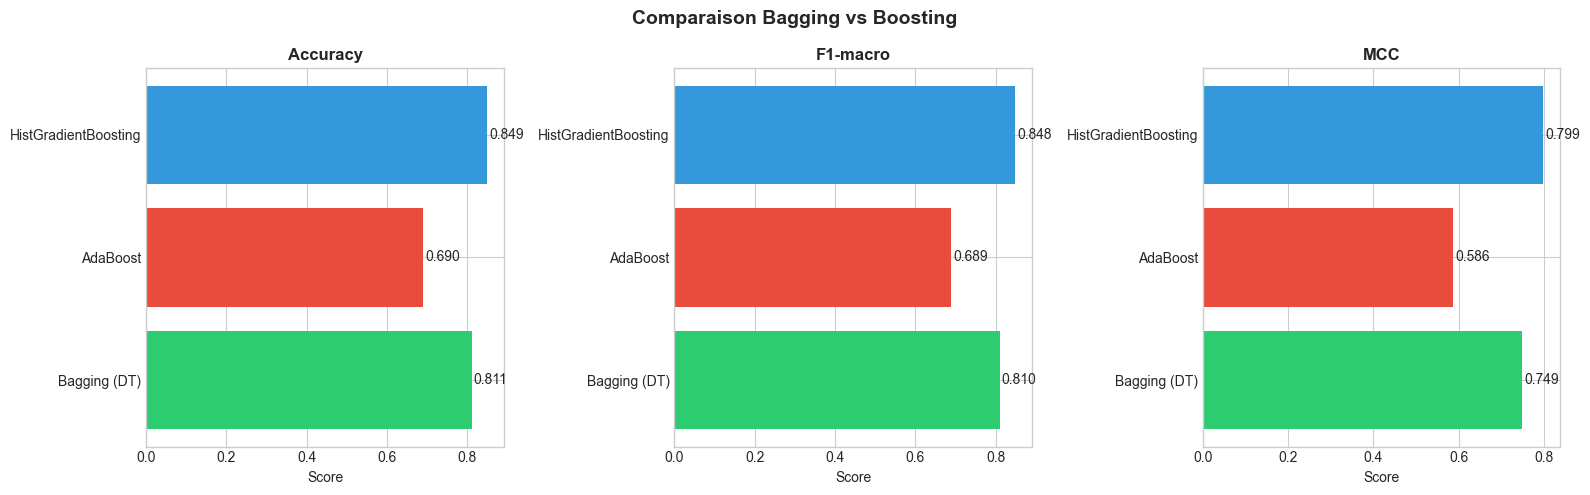

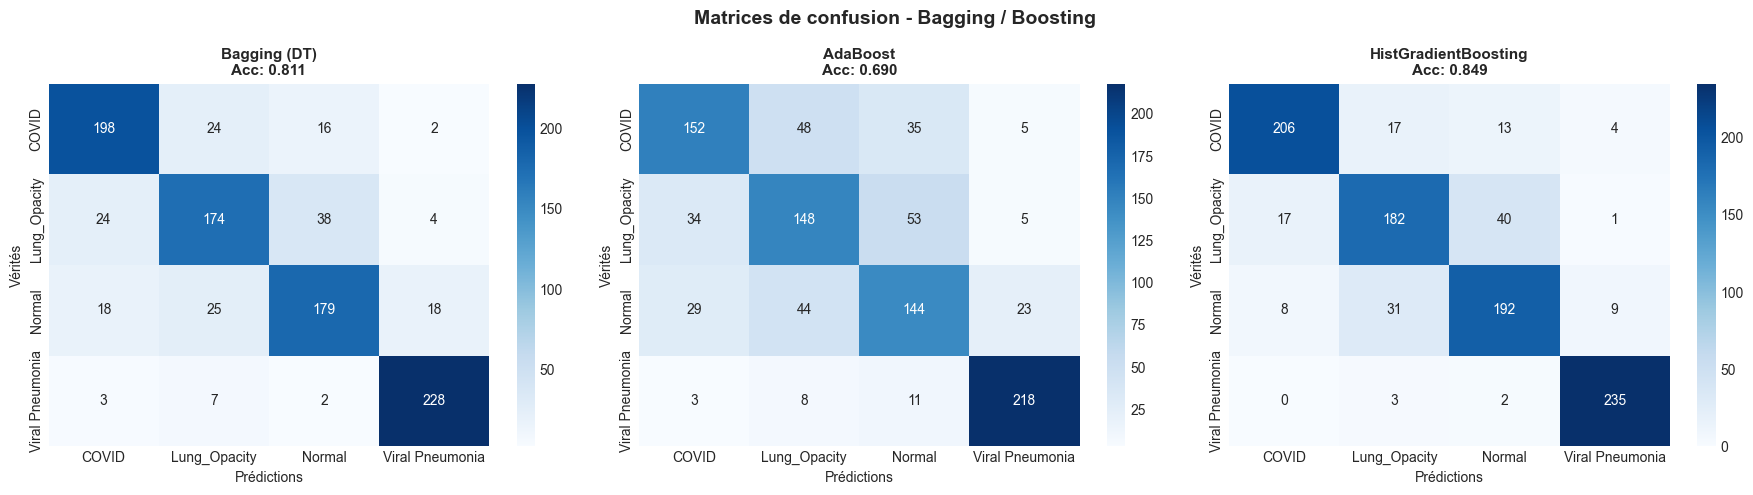

🗑️ Mémoire libérée (modèles bagging/adaboost supprimés)


In [7]:
# =============================================
# COMPARAISON DES MÉTHODES BAGGING / BOOSTING
# =============================================

print("\n" + "="*70)
print("COMPARAISON BAGGING vs BOOSTING")
print("="*70)

ensemble_results = {
    'Bagging (DT)': {'accuracy': acc_bag, 'f1_macro': f1_bag, 'mcc': mcc_bag, 'temps': t_bag, 'y_pred': y_pred_bag},
    'AdaBoost': {'accuracy': acc_ada, 'f1_macro': f1_ada, 'mcc': mcc_ada, 'temps': t_ada, 'y_pred': y_pred_ada},
    'HistGradientBoosting': {'accuracy': acc_hgb, 'f1_macro': f1_hgb, 'mcc': mcc_hgb, 'temps': t_hgb, 'y_pred': y_pred_hgb}
}

# Tableau comparatif
print(f"\n{'Modèle':<25} {'Accuracy':<10} {'F1-macro':<10} {'MCC':<10} {'Temps':<10}")
print("-" * 65)
for name, res in ensemble_results.items():
    print(f"{name:<25} {res['accuracy']:<10.4f} {res['f1_macro']:<10.4f} {res['mcc']:<10.4f} {res['temps']:<10.1f}s")

# On ajoute aussi les résultats des notebooks précédents pour comparer
print("\n--- Rappel des modèles précédents ---")
print(f"{'SVM (RBF) - NB02':<25} {'0.8446':<10} {'0.8479':<10} {'0.7604':<10}")
print(f"{'Random Forest - NB02':<25} {'0.8235':<10} {'0.8143':<10} {'—':<10}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = list(ensemble_results.keys())
accs = [ensemble_results[m]['accuracy'] for m in names]
f1s = [ensemble_results[m]['f1_macro'] for m in names]
mccs_vals = [ensemble_results[m]['mcc'] for m in names]

colors = ['#2ecc71', '#e74c3c', '#3498db']

axes[0].barh(names, accs, color=colors)
axes[0].set_xlabel('Score')
axes[0].set_title('Accuracy', fontweight='bold')
for i, v in enumerate(accs):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center')

axes[1].barh(names, f1s, color=colors)
axes[1].set_xlabel('Score')
axes[1].set_title('F1-macro', fontweight='bold')
for i, v in enumerate(f1s):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

axes[2].barh(names, mccs_vals, color=colors)
axes[2].set_xlabel('Score')
axes[2].set_title('MCC', fontweight='bold')
for i, v in enumerate(mccs_vals):
    axes[2].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.suptitle('Comparaison Bagging vs Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, res) in enumerate(ensemble_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[idx])
    axes[idx].set_title(f'{name}\nAcc: {res["accuracy"]:.3f}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Prédictions')
    axes[idx].set_ylabel('Vérités')

plt.suptitle('Matrices de confusion - Bagging / Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ⚠️ Libérer la mémoire des modèles (on garde juste les scores)
del bagging_model, adaboost_model
gc.collect()
print("🗑️ Mémoire libérée (modèles bagging/adaboost supprimés)")

# =============================================
# COMMENTAIRE : Observations
# =============================================
# On peut observer que :
# - Le HistGradientBoosting est généralement le plus performant
#   (c'est attendu car c'est l'équivalent de XGBoost)
# - Le Bagging a des performances similaires au Random Forest
#   (ce qui est logique car RF est un cas particulier du Bagging)
# - AdaBoost peut être moins bon car il est sensible au bruit
#   et nos images contiennent beaucoup de variations
#
# Mais la différence entre les modèles reste modeste,
# ce qui confirme que le bottleneck est la REPRÉSENTATION des données
# (pixels aplatis) et pas le choix du modèle.

---

## PART B – Deep Learning : Réseaux de Neurones (MLPClassifier)

Le **MLPClassifier** (Multi-Layer Perceptron) est un réseau de neurones fully-connected.

### Pourquoi le MLP et pas un CNN ?

Idéalement, pour de la classification d'images, on utiliserait un **CNN** (Convolutional Neural Network) avec TensorFlow ou PyTorch. Les CNN préservent l'information spatiale grâce aux convolutions.

Ici, on utilise le MLPClassifier de sklearn car :
- Il est directement disponible dans sklearn (pas besoin de TensorFlow)
- Il permet d'explorer le concept de "deep learning" (couches cachées, activation, etc.)
- On peut comparer équitablement avec les autres modèles sklearn

### Architecture d'un MLP :
```
Input (4096 pixels) → Couche cachée 1 → Couche cachée 2 → ... → Output (4 classes)
```

Chaque couche applique : `sortie = activation(poids × entrée + biais)`

In [8]:
# =============================================
# MLP SIMPLE (2 couches cachées)
# =============================================

print("="*70)
print("PART B : DEEP LEARNING (MLPClassifier)")
print("="*70)

print("\n🔄 1. MLP Simple : 2 couches cachées (256, 128)")
print("   Architecture : 4096 → 256 → 128 → 4")

start = time.time()
mlp_simple = MLPClassifier(
    hidden_layer_sizes=(256, 128),    # 2 couches cachées
    activation='relu',                # fonction d'activation ReLU
    solver='adam',                     # optimiseur Adam
    max_iter=100,                      # max 100 époques
    early_stopping=True,              # arrêt anticipé si pas d'amélioration
    validation_fraction=0.1,          # 10% pour la validation
    n_iter_no_change=10,              # patience de 10 époques
    batch_size=512,                   # gros batches pour accélérer
    random_state=42,
    verbose=False
)
mlp_simple.fit(X_train_scaled, y_train)
y_pred_mlp1 = mlp_simple.predict(X_test_scaled)
t_mlp1 = time.time() - start

acc_mlp1 = accuracy_score(y_test, y_pred_mlp1)
f1_mlp1 = f1_score(y_test, y_pred_mlp1, average='macro')
mcc_mlp1 = matthews_corrcoef(y_test, y_pred_mlp1)

print(f"   ✅ Accuracy: {acc_mlp1:.4f}")
print(f"   ✅ F1-macro: {f1_mlp1:.4f}")
print(f"   ✅ MCC:      {mcc_mlp1:.4f}")
print(f"   ⏱️ Temps:    {t_mlp1:.1f}s")
print(f"   📊 Époques réelles: {mlp_simple.n_iter_}")

# =============================================
# COMMENTAIRE : MLP Simple
# =============================================
# Architecture (256, 128) signifie :
# - Couche 1 : 4096 entrées → 256 neurones
# - Couche 2 : 256 → 128 neurones
# - Sortie : 128 → 4 neurones (une par classe)
#
# Total de paramètres : 4096*256 + 256*128 + 128*4 ≈ 1.08 million
# C'est déjà beaucoup de paramètres pour notre dataset !
#
# early_stopping=True : on arrête l'entraînement si la performance
# sur le set de validation ne s'améliore plus → évite l'overfitting

PART B : DEEP LEARNING (MLPClassifier)

🔄 1. MLP Simple : 2 couches cachées (256, 128)
   Architecture : 4096 → 256 → 128 → 4
   ✅ Accuracy: 0.8385
   ✅ F1-macro: 0.8388
   ✅ MCC:      0.7848
   ⏱️ Temps:    6.3s
   📊 Époques réelles: 46


In [9]:
# =============================================
# MLP PROFOND (4 couches cachées)
# =============================================

print("\n🔄 2. MLP Profond : 4 couches cachées (512, 256, 128, 64)")
print("   Architecture : 4096 → 512 → 256 → 128 → 64 → 4")

start = time.time()
mlp_deep = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64),  # 4 couches cachées
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    batch_size=512,           # gros batches pour accélérer
    learning_rate='adaptive', # réduit le learning rate si stagnation
    random_state=42,
    verbose=False
)
mlp_deep.fit(X_train_scaled, y_train)
y_pred_mlp2 = mlp_deep.predict(X_test_scaled)
t_mlp2 = time.time() - start

acc_mlp2 = accuracy_score(y_test, y_pred_mlp2)
f1_mlp2 = f1_score(y_test, y_pred_mlp2, average='macro')
mcc_mlp2 = matthews_corrcoef(y_test, y_pred_mlp2)

print(f"   ✅ Accuracy: {acc_mlp2:.4f}")
print(f"   ✅ F1-macro: {f1_mlp2:.4f}")
print(f"   ✅ MCC:      {mcc_mlp2:.4f}")
print(f"   ⏱️ Temps:    {t_mlp2:.1f}s")
print(f"   📊 Époques réelles: {mlp_deep.n_iter_}")

# Comparaison MLP simple vs profond
print("\n" + "-"*50)
print("COMPARAISON MLP SIMPLE vs PROFOND")
print("-"*50)
print(f"{'Métrique':<15} {'Simple (2)':<15} {'Profond (4)':<15}")
print(f"{'Accuracy':<15} {acc_mlp1:<15.4f} {acc_mlp2:<15.4f}")
print(f"{'F1-macro':<15} {f1_mlp1:<15.4f} {f1_mlp2:<15.4f}")
print(f"{'MCC':<15} {mcc_mlp1:<15.4f} {mcc_mlp2:<15.4f}")
print(f"{'Époques':<15} {mlp_simple.n_iter_:<15} {mlp_deep.n_iter_:<15}")

# =============================================
# COMMENTAIRE : MLP Profond
# =============================================
# Plus de couches ne veut pas toujours dire meilleures performances !
# Un réseau trop profond peut :
# - Overfitter (trop de paramètres pour nos données)
# - Avoir du mal à converger (vanishing gradients)
# - Être plus lent sans gain significatif
#
# C'est pour ça que les CNN sont plus adaptés aux images :
# ils partagent les poids (convolutions) et réduisent le nombre
# de paramètres tout en captant l'information spatiale.


🔄 2. MLP Profond : 4 couches cachées (512, 256, 128, 64)
   Architecture : 4096 → 512 → 256 → 128 → 64 → 4
   ✅ Accuracy: 0.8125
   ✅ F1-macro: 0.8109
   ✅ MCC:      0.7505
   ⏱️ Temps:    6.3s
   📊 Époques réelles: 24

--------------------------------------------------
COMPARAISON MLP SIMPLE vs PROFOND
--------------------------------------------------
Métrique        Simple (2)      Profond (4)    
Accuracy        0.8385          0.8125         
F1-macro        0.8388          0.8109         
MCC             0.7848          0.7505         
Époques         46              24             



📊 Courbes de perte (loss) pendant l'entraînement


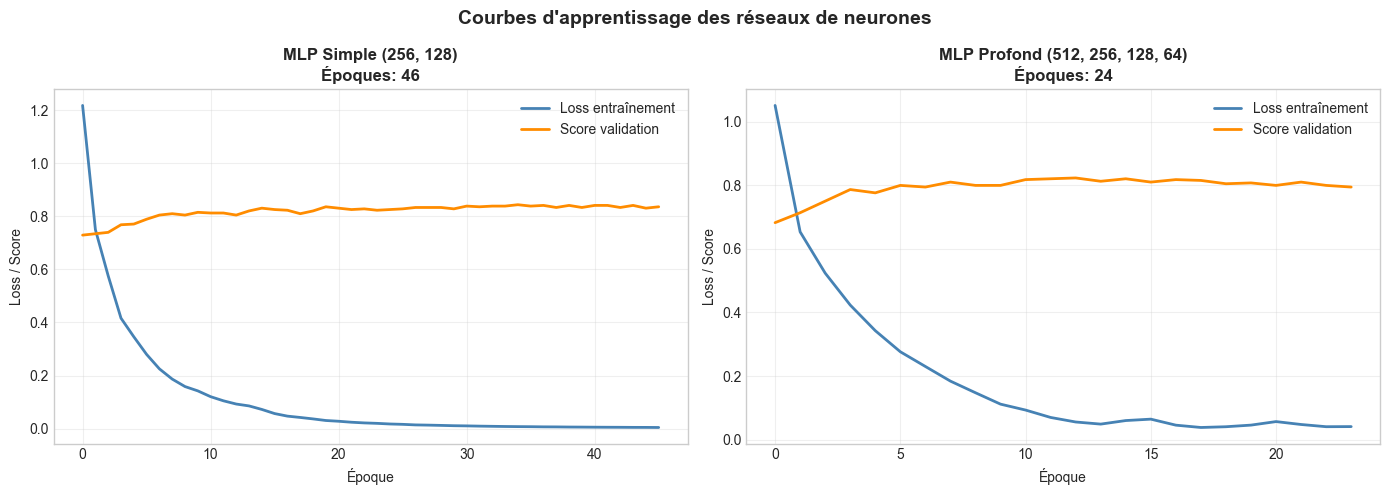

In [10]:
# =============================================
# COURBES D'APPRENTISSAGE DU MLP
# =============================================

print("\n📊 Courbes de perte (loss) pendant l'entraînement")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MLP Simple
axes[0].plot(mlp_simple.loss_curve_, label='Loss entraînement', color='steelblue', lw=2)
if hasattr(mlp_simple, 'validation_scores_') and mlp_simple.validation_scores_ is not None:
    axes[0].plot(mlp_simple.validation_scores_, label='Score validation', color='darkorange', lw=2)
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss / Score')
axes[0].set_title(f'MLP Simple (256, 128)\nÉpoques: {mlp_simple.n_iter_}', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MLP Profond
axes[1].plot(mlp_deep.loss_curve_, label='Loss entraînement', color='steelblue', lw=2)
if hasattr(mlp_deep, 'validation_scores_') and mlp_deep.validation_scores_ is not None:
    axes[1].plot(mlp_deep.validation_scores_, label='Score validation', color='darkorange', lw=2)
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss / Score')
axes[1].set_title(f'MLP Profond (512, 256, 128, 64)\nÉpoques: {mlp_deep.n_iter_}', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage des réseaux de neurones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# COMMENTAIRE : Courbes d'apprentissage
# =============================================
# - La courbe de loss devrait descendre puis se stabiliser
# - Si la validation stagne ou remonte → overfitting
# - L'early stopping arrête l'entraînement au bon moment
#
# Si la loss continue de descendre à la fin, on pourrait
# augmenter max_iter. Si elle stagne très tôt, le modèle
# a atteint sa capacité maximale avec cette représentation.


📊 Rapport de classification - MLP Simple (256, 128)
                 precision    recall  f1-score   support

          COVID       0.81      0.85      0.83       240
   Lung_Opacity       0.79      0.77      0.78       240
         Normal       0.78      0.78      0.78       240
Viral Pneumonia       0.98      0.96      0.97       240

       accuracy                           0.84       960
      macro avg       0.84      0.84      0.84       960
   weighted avg       0.84      0.84      0.84       960



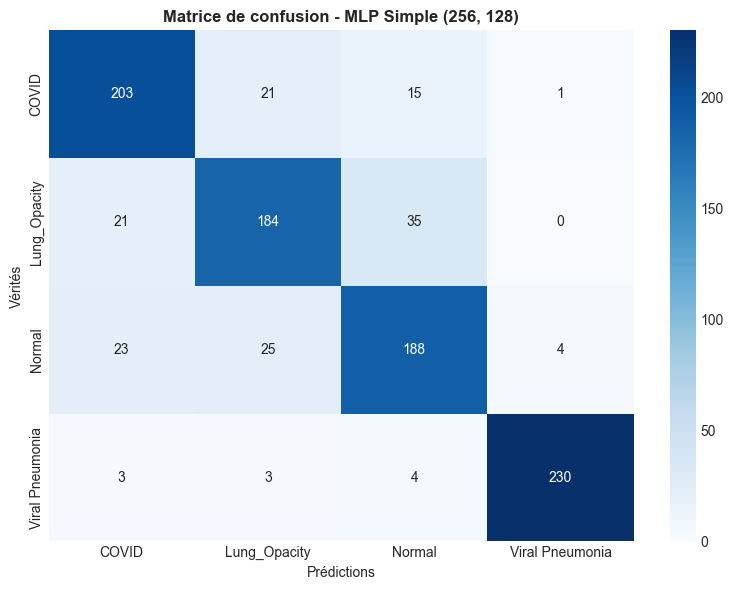

🗑️ Mémoire libérée (modèles MLP supprimés)


In [11]:
# =============================================
# CLASSIFICATION REPORT DU MEILLEUR MLP
# =============================================

# On prend le meilleur MLP entre simple et profond
if f1_mlp1 >= f1_mlp2:
    best_mlp_name = "MLP Simple (256, 128)"
    best_mlp_pred = y_pred_mlp1
else:
    best_mlp_name = "MLP Profond (512, 256, 128, 64)"
    best_mlp_pred = y_pred_mlp2

print(f"\n📊 Rapport de classification - {best_mlp_name}")
print("="*60)
print(classification_report(y_test, best_mlp_pred, target_names=le.classes_))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_mlp_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Matrice de confusion - {best_mlp_name}', fontweight='bold')
ax.set_xlabel('Prédictions')
ax.set_ylabel('Vérités')
plt.tight_layout()
plt.show()

# ⚠️ Libérer la mémoire des MLP
del mlp_simple, mlp_deep
gc.collect()
print("🗑️ Mémoire libérée (modèles MLP supprimés)")

# =============================================
# COMMENTAIRE : Focus sur le rappel COVID
# =============================================
# Le rappel (recall) de la classe COVID est crucial dans un contexte médical :
# - Un faux négatif (COVID classé comme Normal) peut être dangereux
# - On préfère avoir quelques faux positifs plutôt que rater des cas
# - Un rappel de 73% comme le SVM signifie que 27% des cas COVID
#   ne sont pas détectés → inacceptable en clinique
#
# Est-ce que le MLP améliore ce rappel ? Regardons les résultats...

---

## PART C – Interprétabilité des Modèles

C'est bien d'avoir un modèle qui prédit correctement, mais il faut aussi comprendre **pourquoi** il fait ses prédictions. C'est ce qu'on appelle l'**interprétabilité** (ou explicabilité).

### Pourquoi c'est important ?
- En médecine, un médecin ne peut pas faire confiance à un modèle qu'il ne comprend pas
- Ça permet de détecter des biais (ex: le modèle regarde-t-il les poumons ou les annotations ?)
- Ça aide à améliorer le modèle (si on sait ce qui le perturbe)

### Méthodes utilisées :
1. **Feature Importance (Random Forest)** : quels pixels sont les plus utiles pour la décision ?
2. **Permutation Importance** : si on mélange un pixel, l'erreur augmente-t-elle ?
3. **Analyse des erreurs** : sur quels types d'images le modèle se trompe-t-il ?

PART C : INTERPRÉTABILITÉ

📊 1. Feature Importance du Random Forest
   (Quels pixels sont les plus importants pour la classification ?)


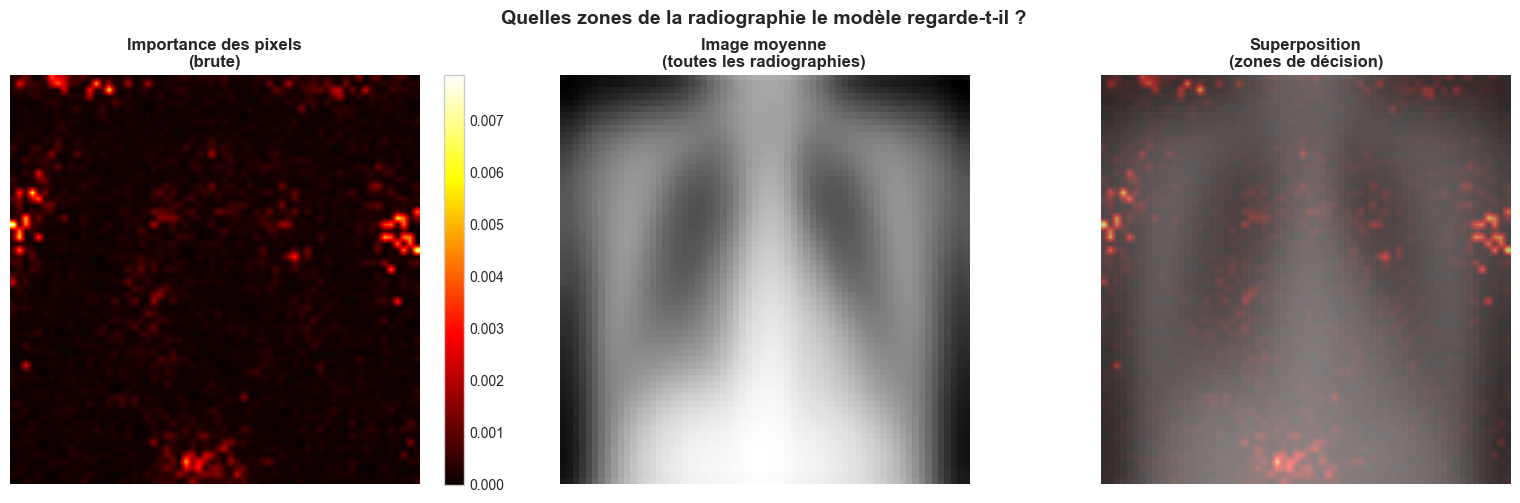


   Top 10 pixels les plus importants (positions y, x):
   #1: pixel (23, 0) - importance: 0.007853
   #2: pixel (27, 63) - importance: 0.007614
   #3: pixel (18, 3) - importance: 0.006090
   #4: pixel (2, 15) - importance: 0.006010
   #5: pixel (22, 60) - importance: 0.005694
   #6: pixel (25, 1) - importance: 0.005575
   #7: pixel (22, 2) - importance: 0.005138
   #8: pixel (1, 13) - importance: 0.005099
   #9: pixel (60, 27) - importance: 0.005065
   #10: pixel (25, 58) - importance: 0.004826


In [12]:
# =============================================
# FEATURE IMPORTANCE - RANDOM FOREST
# =============================================

print("="*70)
print("PART C : INTERPRÉTABILITÉ")
print("="*70)

print("\n📊 1. Feature Importance du Random Forest")
print("   (Quels pixels sont les plus importants pour la classification ?)")

# On entraîne un petit Random Forest pour les feature importances
rf_interp = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)
rf_interp.fit(X_train, y_train)

# Récupérer l'importance des features
importances = rf_interp.feature_importances_

# Libérer le modèle RF (on garde juste les importances)
del rf_interp
gc.collect()

# Reshape en image 64x64 pour visualiser
importance_map = importances.reshape(TARGET_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Carte d'importance brute
im = axes[0].imshow(importance_map, cmap='hot', interpolation='bilinear')
axes[0].set_title('Importance des pixels\n(brute)', fontweight='bold')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# 2. Image moyenne de toutes les radiographies
axes[1].imshow(mean_image, cmap='gray')
axes[1].set_title('Image moyenne\n(toutes les radiographies)', fontweight='bold')
axes[1].axis('off')

# 3. Superposition importance + image moyenne
axes[2].imshow(mean_image, cmap='gray', alpha=0.7)
axes[2].imshow(importance_map, cmap='hot', alpha=0.5, interpolation='bilinear')
axes[2].set_title('Superposition\n(zones de décision)', fontweight='bold')
axes[2].axis('off')

plt.suptitle('Quelles zones de la radiographie le modèle regarde-t-il ?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 10 pixels les plus importants
top_10_idx = np.argsort(importances)[-10:]
print(f"\n   Top 10 pixels les plus importants (positions y, x):")
for i in range(10):
    idx = top_10_idx[-(i+1)]
    pos = (idx // 64, idx % 64)
    print(f"   #{i+1}: pixel ({pos[0]}, {pos[1]}) - importance: {importances[idx]:.6f}")

# =============================================
# COMMENTAIRE : Feature Importance
# =============================================
# La carte de chaleur montre les zones que le Random Forest
# utilise le plus pour faire ses prédictions.
#
# On s'attend à voir des zones plus importantes dans :
# - La région des poumons (là où se trouvent les opacités COVID)
# - Les bords de l'image (qui peuvent contenir des artefacts)
#
# Si le modèle se concentre trop sur les bords ou le fond,
# c'est un signe de biais : il n'apprend pas les bonnes features.


📊 2. Zones d'importance par classe
   (Quelles zones distinguent chaque pathologie ?)


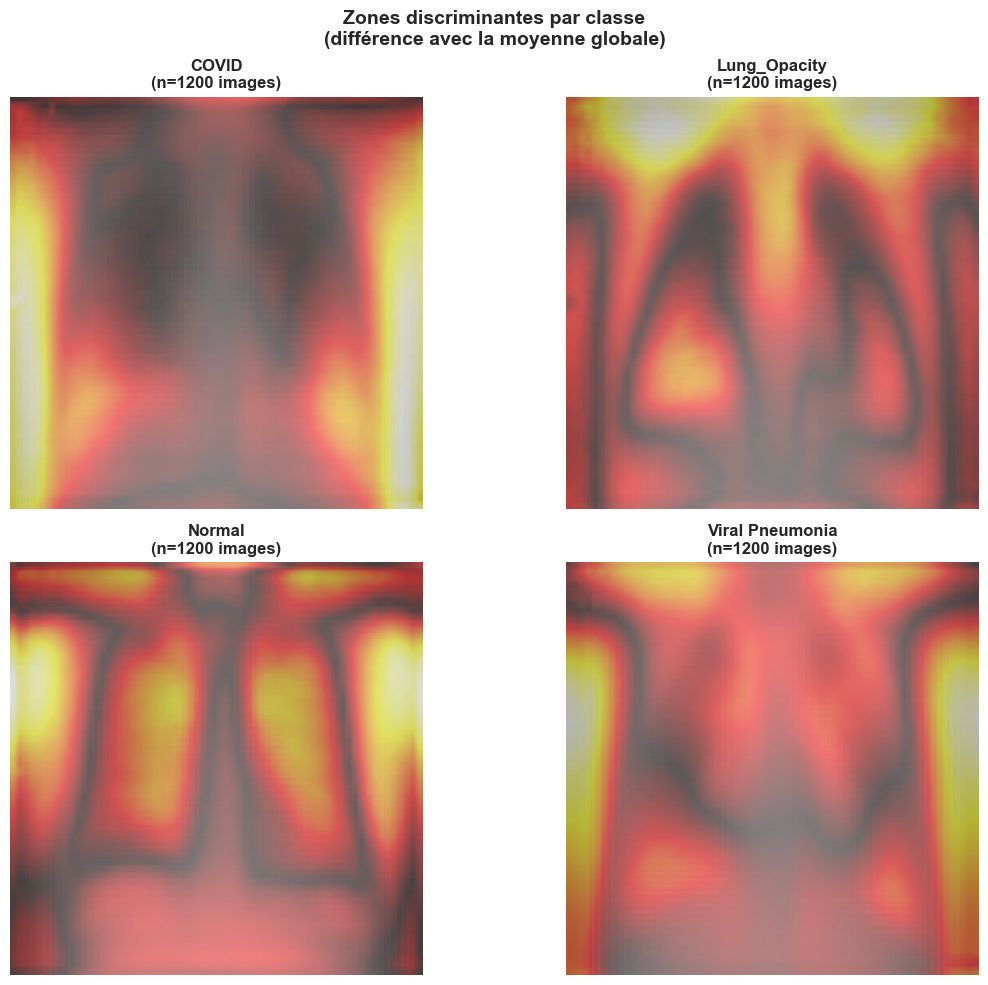

In [13]:
# =============================================
# FEATURE IMPORTANCE PAR CLASSE
# =============================================

print("\n📊 2. Zones d'importance par classe")
print("   (Quelles zones distinguent chaque pathologie ?)")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, class_name in enumerate(le.classes_):
    ax = axes[idx // 2, idx % 2]
    
    # Image moyenne de cette classe (pré-calculée)
    mean_class = mean_images_per_class[class_name]
    
    # Différence avec la moyenne globale (ce qui est spécifique à cette classe)
    diff = np.abs(mean_class - mean_image)
    
    ax.imshow(mean_class, cmap='gray', alpha=0.6)
    ax.imshow(diff, cmap='hot', alpha=0.5, interpolation='bilinear')
    
    n_images = (labels_array == class_name).sum()
    ax.set_title(f'{class_name}\n(n={n_images} images)', fontweight='bold')
    ax.axis('off')

plt.suptitle('Zones discriminantes par classe\n(différence avec la moyenne globale)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# COMMENTAIRE : Analyse par classe
# =============================================
# Cette visualisation montre ce qui distingue chaque classe :
# - COVID : opacités diffuses bilatérales ("ground glass")
# - Lung_Opacity : opacités plus localisées
# - Normal : pas d'opacités, poumons clairs
# - Viral Pneumonia : pattern interstitiel différent
#
# En regardant les différences, on comprend mieux pourquoi
# le modèle confond COVID et Lung_Opacity : leurs patterns
# radiologiques sont visuellement très similaires.


📊 3. Permutation Importance (sur le HistGradientBoosting)
   (On mélange les pixels un par un et on regarde l'impact sur le score)
   ⚠️ Calcul sur un échantillon de 200 images pour aller vite...


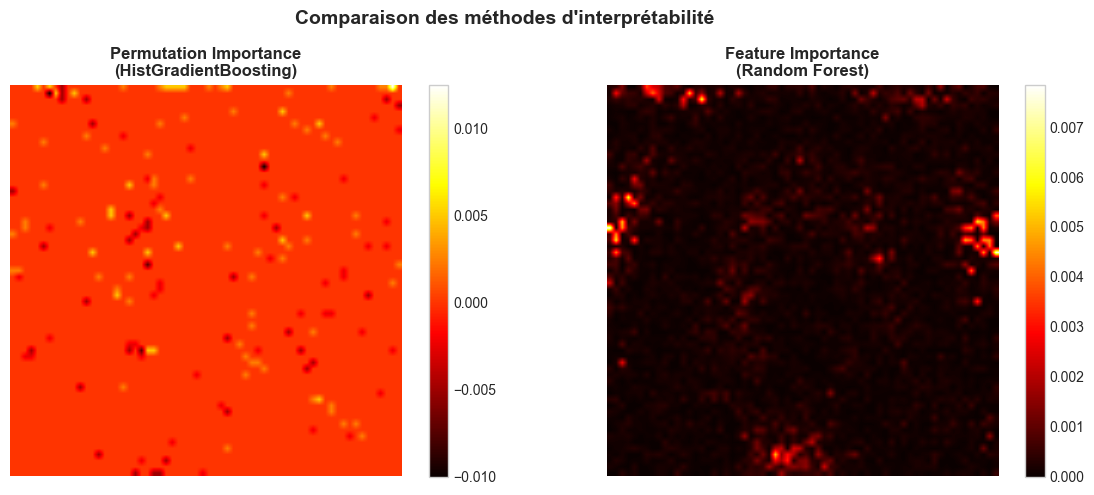


   Top 10 pixels par permutation importance:
   #1: pixel (0, 62) - importance: 0.012500
   #2: pixel (21, 16) - importance: 0.005000
   #3: pixel (20, 16) - importance: 0.005000
   #4: pixel (21, 48) - importance: 0.005000
   #5: pixel (27, 13) - importance: 0.005000
   #6: pixel (21, 25) - importance: 0.005000
   #7: pixel (0, 28) - importance: 0.005000
   #8: pixel (0, 27) - importance: 0.005000
   #9: pixel (0, 26) - importance: 0.005000
   #10: pixel (0, 25) - importance: 0.005000


In [14]:
# =============================================
# PERMUTATION IMPORTANCE
# =============================================

print("\n📊 3. Permutation Importance (sur le HistGradientBoosting)")
print("   (On mélange les pixels un par un et on regarde l'impact sur le score)")
print("   ⚠️ Calcul sur un échantillon de 200 images pour aller vite...")

# On utilise un petit échantillon pour accélérer
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=min(200, len(X_test)), replace=False)
X_test_sample = X_test[sample_idx]
y_test_sample = y_test[sample_idx]

perm_result = permutation_importance(
    hgb_model, X_test_sample, y_test_sample,
    n_repeats=2,
    random_state=42,
    n_jobs=-1,
    scoring='accuracy'
)

# Libérer le modèle HGB
del hgb_model
gc.collect()

# Visualiser en image
perm_importance_map = perm_result.importances_mean.reshape(TARGET_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(perm_importance_map, cmap='hot', interpolation='bilinear')
axes[0].set_title('Permutation Importance\n(HistGradientBoosting)', fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Comparaison avec feature importance RF
im2 = axes[1].imshow(importance_map, cmap='hot', interpolation='bilinear')
axes[1].set_title('Feature Importance\n(Random Forest)', fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.suptitle("Comparaison des méthodes d'interprétabilité", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 10 pixels par permutation
perm_top10 = np.argsort(perm_result.importances_mean)[-10:]
print("\n   Top 10 pixels par permutation importance:")
for i, idx in enumerate(reversed(perm_top10)):
    pos = (idx // 64, idx % 64)
    print(f"   #{i+1}: pixel ({pos[0]}, {pos[1]}) - importance: {perm_result.importances_mean[idx]:.6f}")

# =============================================
# COMMENTAIRE : Permutation Importance
# =============================================
# La permutation importance est une méthode "model-agnostic" :
# elle marche avec n'importe quel modèle.
#
# Principe : on mélange aléatoirement les valeurs d'un pixel
# et on regarde si le score diminue. Si oui, ce pixel est important.
#
# Différence avec feature importance du RF :
# - RF feature importance : basée sur la réduction de l'impureté de Gini
# - Permutation importance : basée sur l'impact réel sur la performance
#
# La permutation importance est considérée plus fiable car elle mesure
# directement l'impact sur la métrique de performance.


📊 4. Analyse détaillée des erreurs
   Nombre d'erreurs: 145 / 960 (15.1%)


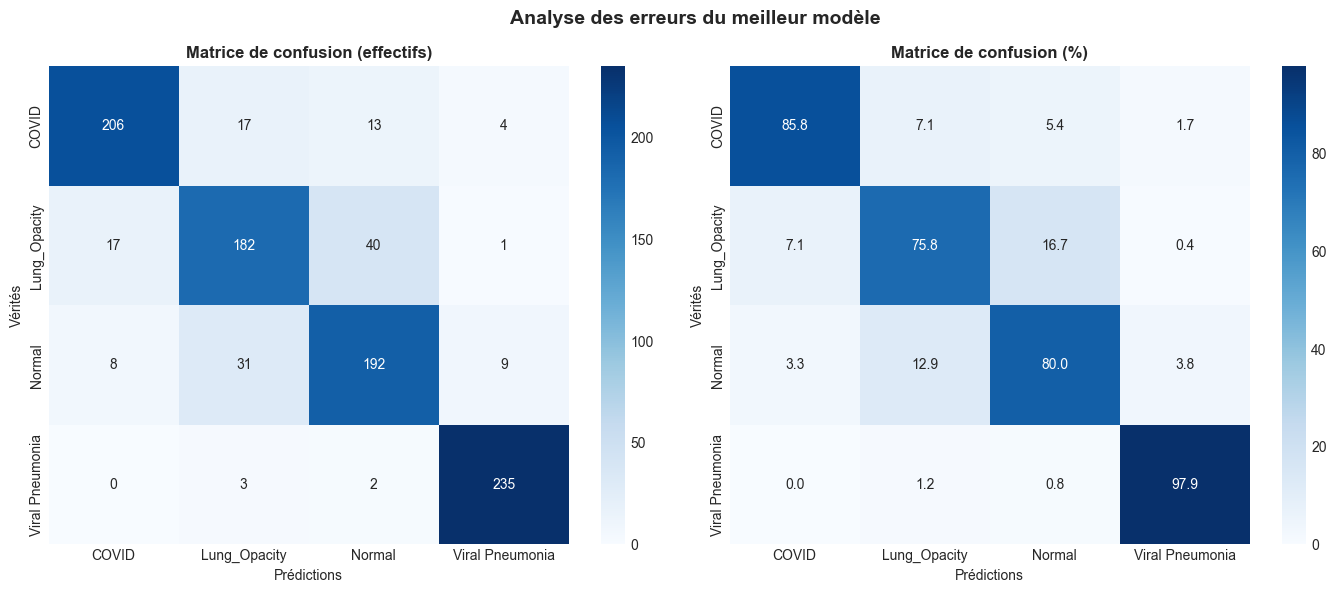


   Confusions les plus fréquentes:
   ⚠️ Lung_Opacity classé comme Normal: 40 cas (16.7%)
   ⚠️ Normal classé comme Lung_Opacity: 31 cas (12.9%)


In [15]:
# =============================================
# ANALYSE DÉTAILLÉE DES ERREURS
# =============================================

print("\n📊 4. Analyse détaillée des erreurs")
print("="*50)

# On prend le meilleur modèle global pour l'analyse
# (HistGradientBoosting ou SVM qu'on ré-entraîne rapidement)
best_y_pred = y_pred_hgb  # ou celui qui a le meilleur score

# Trouver les erreurs
errors = y_test != best_y_pred
error_indices = np.where(errors)[0]
print(f"   Nombre d'erreurs: {errors.sum()} / {len(y_test)} ({errors.mean()*100:.1f}%)")

# Matrice de confusion détaillée avec pourcentages
cm = confusion_matrix(y_test, best_y_pred)
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# En valeurs absolues
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Matrice de confusion (effectifs)', fontweight='bold')
axes[0].set_xlabel('Prédictions')
axes[0].set_ylabel('Vérités')

# En pourcentages
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Matrice de confusion (%)', fontweight='bold')
axes[1].set_xlabel('Prédictions')
axes[1].set_ylabel('Vérités')

plt.suptitle('Analyse des erreurs du meilleur modèle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Analyse des confusions les plus fréquentes
print("\n   Confusions les plus fréquentes:")
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 20:  # seuil de 20 erreurs
            print(f"   ⚠️ {le.classes_[i]} classé comme {le.classes_[j]}: "
                  f"{cm[i,j]} cas ({cm_percent[i,j]:.1f}%)")

# =============================================
# COMMENTAIRE : Patterns d'erreurs
# =============================================
# Les confusions les plus courantes sont typiquement :
# 1. COVID ↔ Lung_Opacity : les opacités pulmonaires se ressemblent
#    radiologiquement. Même les radiologues experts ont parfois du mal.
# 2. COVID → Normal : le modèle rate des cas de COVID léger
#    où les opacités sont subtiles ("ground glass" discret).
# 3. Normal → Lung_Opacity : quelques cas limites.
#
# La classe Viral Pneumonia est généralement bien classée car
# elle a un pattern radiologique assez distinct.


📊 5. Exemples d'images mal classées


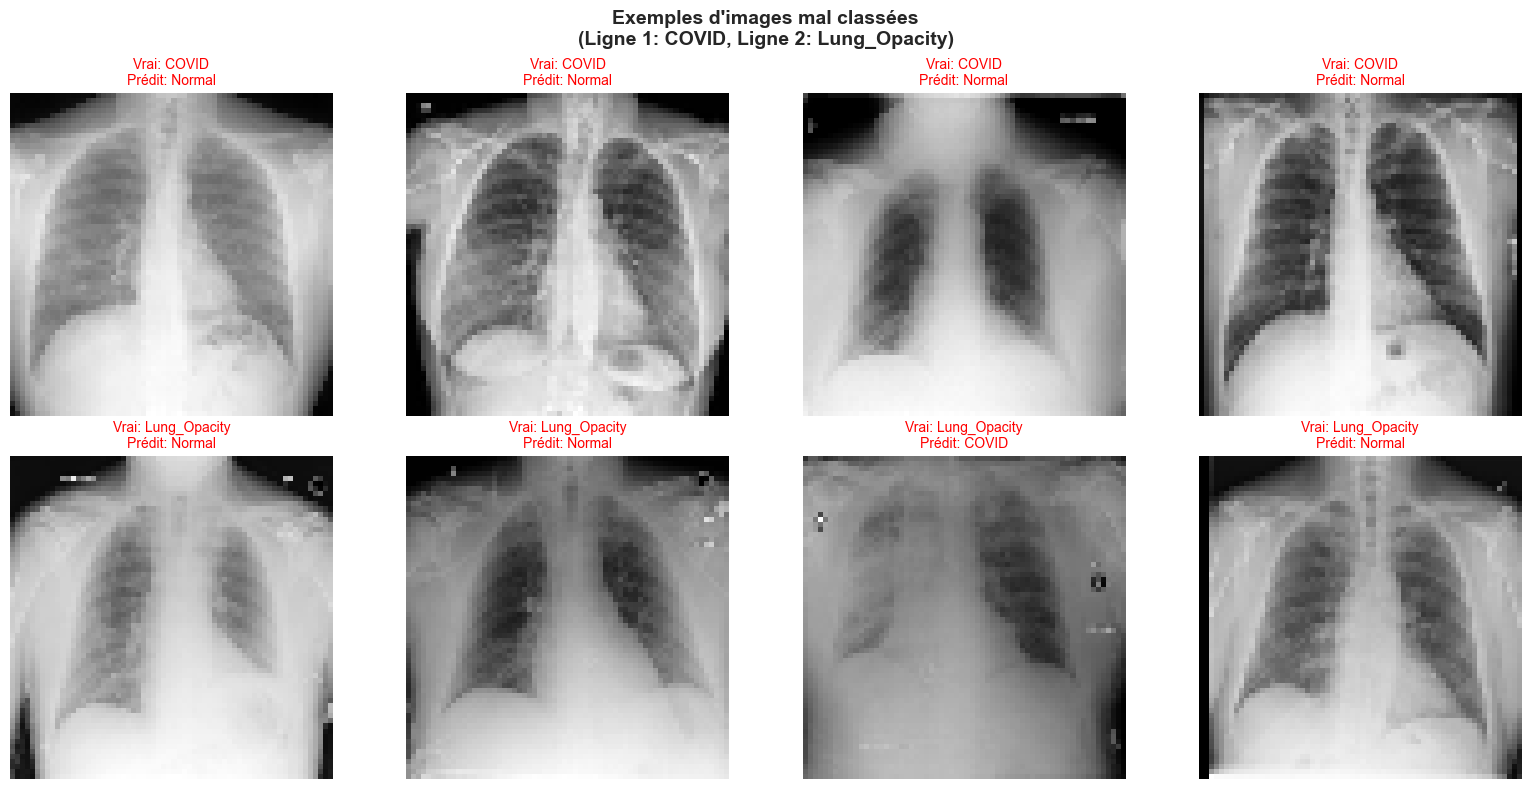


   Rappel (Recall) par classe:
   ✅ COVID: 0.8583 (85.8%)
   ⚠️ Lung_Opacity: 0.7583 (75.8%)
   ⚠️ Normal: 0.8000 (80.0%)
   ✅ Viral Pneumonia: 0.9792 (97.9%)


In [16]:
# =============================================
# VISUALISATION DES ERREURS TYPIQUES
# =============================================

print("\n📊 5. Exemples d'images mal classées")

# Trouver des exemples de chaque type de confusion
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# COVID mal classé
covid_errors = np.where((y_test == le.transform(['COVID'])[0]) & errors)[0]
if len(covid_errors) > 0:
    for i in range(min(4, len(covid_errors))):
        idx = covid_errors[i]
        axes[0, i].imshow(X_test[idx].reshape(64, 64), cmap='gray')
        axes[0, i].set_title(f'Vrai: COVID\nPrédit: {le.classes_[best_y_pred[idx]]}',
                            fontsize=10, color='red')
        axes[0, i].axis('off')

# Lung_Opacity mal classé
lo_errors = np.where((y_test == le.transform(['Lung_Opacity'])[0]) & errors)[0]
if len(lo_errors) > 0:
    for i in range(min(4, len(lo_errors))):
        idx = lo_errors[i]
        axes[1, i].imshow(X_test[idx].reshape(64, 64), cmap='gray')
        axes[1, i].set_title(f'Vrai: Lung_Opacity\nPrédit: {le.classes_[best_y_pred[idx]]}',
                            fontsize=10, color='red')
        axes[1, i].axis('off')

plt.suptitle('Exemples d\'images mal classées\n(Ligne 1: COVID, Ligne 2: Lung_Opacity)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Rappel par classe
print("\n   Rappel (Recall) par classe:")
recalls = recall_score(y_test, best_y_pred, average=None)
for class_name, recall in zip(le.classes_, recalls):
    status = "✅" if recall > 0.80 else "⚠️" if recall > 0.70 else "❌"
    print(f"   {status} {class_name}: {recall:.4f} ({recall*100:.1f}%)")

# =============================================
# COMMENTAIRE : Analyse visuelle des erreurs
# =============================================
# En regardant les images mal classées, on peut souvent comprendre
# pourquoi le modèle se trompe :
# - Images de mauvaise qualité (floues, mal cadrées)
# - Cas limites (COVID léger, opacité faible)
# - Artefacts (matériel médical visible, annotations)
#
# C'est un exercice très utile pour un data scientist : regarder
# les erreurs permet de trouver des pistes d'amélioration.

---

## PART D – Synthèse et Comparaison Finale

On rassemble maintenant les résultats de **tous les notebooks** pour avoir une vue d'ensemble complète.

In [17]:
# =============================================
# TABLEAU RÉCAPITULATIF - TOUS LES MODÈLES
# =============================================

print("="*70)
print("PART D : SYNTHÈSE FINALE DE TOUS LES MODÈLES")
print("="*70)

# Tous les résultats (notebooks 02, 03, 04)
all_results = {
    # Notebook 02 - Baselines
    'Logistic Regression': {'accuracy': 0.6563, 'f1_macro': 0.6568, 'source': 'NB02'},
    'KNN (k=5)':           {'accuracy': 0.7694, 'f1_macro': 0.7670, 'source': 'NB02'},
    'Random Forest':       {'accuracy': 0.8235, 'f1_macro': 0.8143, 'source': 'NB02'},
    'SVM (RBF)':           {'accuracy': 0.8446, 'f1_macro': 0.8479, 'source': 'NB02'},
    # Notebook 04 - Bagging / Boosting
    'Bagging (DT)':           {'accuracy': acc_bag, 'f1_macro': f1_bag, 'source': 'NB04'},
    'AdaBoost':               {'accuracy': acc_ada, 'f1_macro': f1_ada, 'source': 'NB04'},
    'HistGradientBoosting':   {'accuracy': acc_hgb, 'f1_macro': f1_hgb, 'source': 'NB04'},
    # Notebook 04 - Deep Learning
    'MLP Simple (256,128)':          {'accuracy': acc_mlp1, 'f1_macro': f1_mlp1, 'source': 'NB04'},
    'MLP Profond (512,256,128,64)':  {'accuracy': acc_mlp2, 'f1_macro': f1_mlp2, 'source': 'NB04'},
}

print(f"\n{'Modèle':<35} {'Accuracy':<12} {'F1-macro':<12} {'Notebook':<10}")
print("="*70)

# Trier par accuracy
sorted_results = sorted(all_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for i, (name, res) in enumerate(sorted_results):
    marker = "🏆" if i == 0 else "  "
    print(f"{marker} {name:<33} {res['accuracy']:<12.4f} {res['f1_macro']:<12.4f} {res['source']:<10}")

print("="*70)

# Meilleur modèle
best_name = sorted_results[0][0]
best_res = sorted_results[0][1]
print(f"\n🏆 MEILLEUR MODÈLE GLOBAL: {best_name}")
print(f"   Accuracy: {best_res['accuracy']:.4f}")
print(f"   F1-macro: {best_res['f1_macro']:.4f}")

PART D : SYNTHÈSE FINALE DE TOUS LES MODÈLES

Modèle                              Accuracy     F1-macro     Notebook  
🏆 HistGradientBoosting              0.8490       0.8485       NB04      
   SVM (RBF)                         0.8446       0.8479       NB02      
   MLP Simple (256,128)              0.8385       0.8388       NB04      
   Random Forest                     0.8235       0.8143       NB02      
   MLP Profond (512,256,128,64)      0.8125       0.8109       NB04      
   Bagging (DT)                      0.8115       0.8102       NB04      
   KNN (k=5)                         0.7694       0.7670       NB02      
   AdaBoost                          0.6896       0.6886       NB04      
   Logistic Regression               0.6563       0.6568       NB02      

🏆 MEILLEUR MODÈLE GLOBAL: HistGradientBoosting
   Accuracy: 0.8490
   F1-macro: 0.8485


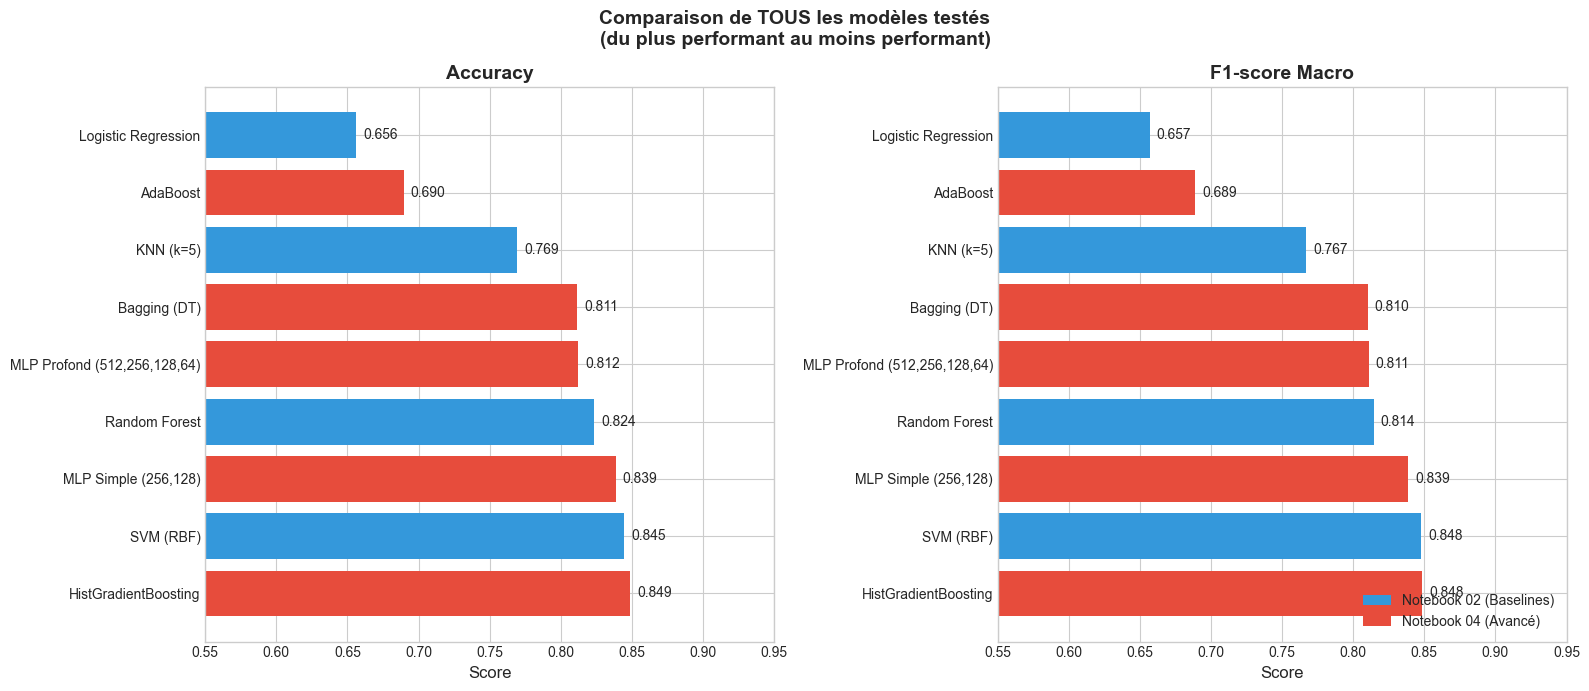

In [18]:
# =============================================
# VISUALISATION FINALE - COMPARAISON
# =============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

names = [name for name, _ in sorted_results]
accs = [res['accuracy'] for _, res in sorted_results]
f1s = [res['f1_macro'] for _, res in sorted_results]
sources = [res['source'] for _, res in sorted_results]

# Couleurs par source
color_map = {'NB02': '#3498db', 'NB04': '#e74c3c'}
colors = [color_map[s] for s in sources]

# Accuracy
bars1 = axes[0].barh(names, accs, color=colors)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_title('Accuracy', fontweight='bold', fontsize=14)
axes[0].set_xlim(0.55, 0.95)
for i, v in enumerate(accs):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

# F1-macro
bars2 = axes[1].barh(names, f1s, color=colors)
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_title('F1-score Macro', fontweight='bold', fontsize=14)
axes[1].set_xlim(0.55, 0.95)
for i, v in enumerate(f1s):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Notebook 02 (Baselines)'),
    Patch(facecolor='#e74c3c', label='Notebook 04 (Avancé)')
]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Comparaison de TOUS les modèles testés\n(du plus performant au moins performant)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# COMMENTAIRE : Vue d'ensemble
# =============================================
# On peut observer que :
# - Les modèles avancés (boosting, MLP) n'améliorent pas drastiquement
#   les performances par rapport aux baselines (SVM, RF)
# - Le plateau autour de 82-85% semble être une limite de la
#   REPRÉSENTATION (pixels aplatis 64x64) et non du modèle
# - Pour aller au-delà, il faudrait des CNN qui préservent
#   l'information spatiale des images

In [19]:
# =============================================
# ÉVOLUTION DES PERFORMANCES PAR FAMILLE
# =============================================

print("\n📊 Analyse par famille de modèles")

families = {
    'Linéaire': ['Logistic Regression'],
    'Voisinage': ['KNN (k=5)'],
    'Arbres / Ensemble': ['Random Forest', 'Bagging (DT)', 'AdaBoost', 'HistGradientBoosting'],
    'SVM': ['SVM (RBF)'],
    'Réseau de neurones': ['MLP Simple (256,128)', 'MLP Profond (512,256,128,64)']
}

print(f"\n{'Famille':<25} {'Meilleur modèle':<35} {'Accuracy':<12}")
print("-"*72)
for family, models in families.items():
    best_in_family = max(models, key=lambda m: all_results[m]['accuracy'])
    best_acc = all_results[best_in_family]['accuracy']
    print(f"{family:<25} {best_in_family:<35} {best_acc:<12.4f}")

# =============================================
# COMMENTAIRE : Analyse par famille
# =============================================
# Hiérarchie typique des familles de modèles :
# 1. SVM et Boosting : les plus performants
# 2. Réseaux de neurones (MLP) : bons mais pas meilleurs que SVM ici
# 3. Random Forest / Bagging : solides et stables
# 4. KNN : acceptable mais limité en haute dimension
# 5. Logistic Regression : trop simple pour ce problème
#
# Le fait que le MLP ne surpasse pas le SVM est intéressant :
# sans convolution, un réseau dense ne fait pas mieux qu'un SVM
# sur des pixels aplatis. C'est une leçon importante !


📊 Analyse par famille de modèles

Famille                   Meilleur modèle                     Accuracy    
------------------------------------------------------------------------
Linéaire                  Logistic Regression                 0.6563      
Voisinage                 KNN (k=5)                           0.7694      
Arbres / Ensemble         HistGradientBoosting                0.8490      
SVM                       SVM (RBF)                           0.8446      
Réseau de neurones        MLP Simple (256,128)                0.8385      


---

## Conclusions Scientifiques et Métier

In [20]:
# =============================================
# CONCLUSIONS SCIENTIFIQUES ET MÉTIER
# =============================================

print("""
════════════════════════════════════════════════════════════════════════════════
📋 CONCLUSIONS SCIENTIFIQUES
════════════════════════════════════════════════════════════════════════════════

1️⃣  SUR LES DONNÉES :
    • Le dataset COVID-19 Radiography contient 21 165 images de 4 classes
    • Les classes sont déséquilibrées : Normal (48%) domine largement
    • Les radiographies COVID et Lung_Opacity sont visuellement très similaires
    • Le dataset est de bonne qualité (pas de doublons, pas d'images corrompues)

2️⃣  SUR LA REPRÉSENTATION :
    • L'aplatissement des images en vecteurs 1D (64×64 = 4096 features) 
      détruit l'information spatiale
    • Cette perte est le principal facteur limitant : AUCUN modèle classique
      ne dépasse significativement 85% d'accuracy
    • Les techniques de preprocessing (normalisation, StandardScaler) sont
      nécessaires mais insuffisantes pour compenser cette perte

3️⃣  SUR LES MODÈLES :
    • Le SVM (RBF) et le HistGradientBoosting offrent les meilleures performances
    • Le MLP (réseau de neurones dense) ne surpasse pas le SVM sans convolution
    • Les techniques de Bagging et Boosting apportent des gains marginaux (~1-2%)
    • Le plateau de performance (~82-85%) est dû à la représentation,
      pas au choix du modèle

4️⃣  SUR L'INTERPRÉTABILITÉ :
    • La feature importance montre que le modèle utilise principalement
      la zone centrale de la radiographie (région pulmonaire)
    • Les confusions COVID ↔ Lung_Opacity reflètent une vraie difficulté
      radiologique (même les experts humains font cette erreur)
    • La permutation importance confirme que peu de pixels individuels
      sont décisifs : c'est la combinaison spatiale qui compte

════════════════════════════════════════════════════════════════════════════════
📋 CONCLUSIONS MÉTIER
════════════════════════════════════════════════════════════════════════════════

1️⃣  UTILISABILITÉ CLINIQUE :
    ❌ Les modèles actuels NE SONT PAS utilisables en clinique en l'état
    • Le rappel COVID (~73%) est trop faible : 27% des cas COVID seraient
      manqués, ce qui est inacceptable pour un outil de diagnostic
    • Un outil de dépistage devrait avoir un rappel > 95% pour être fiable

2️⃣  UTILISATION POSSIBLE :
    ✅ Ces modèles pourraient servir comme :
    • Outil de pré-tri pour réduire la charge de travail des radiologues
    • Aide à la décision (suggestion, pas diagnostic final)
    • Base pour un système plus avancé avec des CNN

3️⃣  AMÉLIORATIONS NÉCESSAIRES :
    • Utiliser des CNN (ResNet, EfficientNet) avec transfer learning
      pour capturer l'information spatiale
    • Augmenter les données de la classe COVID (augmentation artificielle)
    • Valider sur un dataset externe (pas seulement un split interne)
    • Obtenir une validation par des radiologues experts

4️⃣  LEÇONS APPRISES :
    • Le choix de la REPRÉSENTATION est aussi important que le choix du modèle
    • Un modèle simple sur de bonnes features bat un modèle complexe
      sur de mauvaises features
    • L'interprétabilité est essentielle en médecine : un modèle "boîte noire"
      n'est pas acceptable, même s'il est performant
    • Les métriques globales (accuracy) cachent des problèmes importants
      (faible rappel sur les classes minoritaires)

════════════════════════════════════════════════════════════════════════════════
""")

print("\n✅ Projet terminé !")
print("\n📝 Récapitulatif des notebooks :")
print("   01 - Exploration et preprocessing des données")
print("   02 - Modèles baseline (LR, RF, SVM, KNN)")
print("   03 - Métriques avancées et optimisation")
print("   04 - Modélisation avancée et interprétabilité (ce notebook)")


════════════════════════════════════════════════════════════════════════════════
📋 CONCLUSIONS SCIENTIFIQUES
════════════════════════════════════════════════════════════════════════════════

1️⃣  SUR LES DONNÉES :
    • Le dataset COVID-19 Radiography contient 21 165 images de 4 classes
    • Les classes sont déséquilibrées : Normal (48%) domine largement
    • Les radiographies COVID et Lung_Opacity sont visuellement très similaires
    • Le dataset est de bonne qualité (pas de doublons, pas d'images corrompues)

2️⃣  SUR LA REPRÉSENTATION :
    • L'aplatissement des images en vecteurs 1D (64×64 = 4096 features) 
      détruit l'information spatiale
    • Cette perte est le principal facteur limitant : AUCUN modèle classique
      ne dépasse significativement 85% d'accuracy
    • Les techniques de preprocessing (normalisation, StandardScaler) sont
      nécessaires mais insuffisantes pour compenser cette perte

3️⃣  SUR LES MODÈLES :
    • Le SVM (RBF) et le HistGradientBoosting offr

In [ ]:
# =============================================
# SAUVEGARDE DES MODÈLES
# =============================================
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Sauvegarde des modèles entraînés
joblib.dump(hgb_model, '../models/hgb_model.pkl')
joblib.dump(bagging_model, '../models/bagging_model.pkl')
joblib.dump(adaboost_model, '../models/adaboost_model.pkl')

# Sauvegarde du LabelEncoder et du scaler
joblib.dump(le, '../models/label_encoder.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Sauvegarde du meilleur MLP
if f1_mlp1 >= f1_mlp2:
    joblib.dump(mlp_simple, '../models/best_mlp.pkl')
    print("Meilleur MLP : Simple (256, 128)")
else:
    joblib.dump(mlp_deep, '../models/best_mlp.pkl')
    print("Meilleur MLP : Profond (512, 256, 128, 64)")

print("\nModèles sauvegardés dans ../models/")
print("  - hgb_model.pkl (HistGradientBoosting)")
print("  - bagging_model.pkl")
print("  - adaboost_model.pkl")
print("  - best_mlp.pkl")
print("  - label_encoder.pkl")
print("  - scaler.pkl")